In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Datos
https://fred.stlouisfed.org/series/S4248SM144NCEN

In [2]:
df = pd.read_csv('./Alcohol_Sales.csv',index_col='DATE',parse_dates=True)
df.index.freq = 'MS'
df.columns = ['Sales']

In [3]:
df.head()

,Sales
DATE,
1992-01-01,3459
1992-02-01,3458
1992-03-01,4002
1992-04-01,4564
1992-05-01,4221


<Axes: xlabel='DATE'>

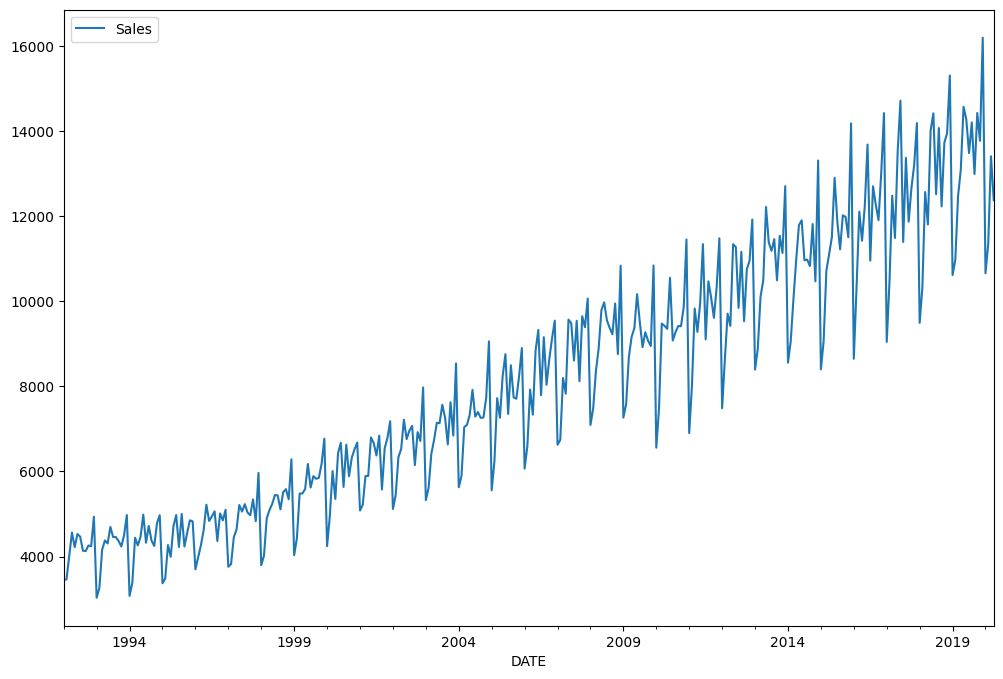

In [4]:
df.plot(figsize=(12,8))

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

<Axes: xlabel='DATE'>

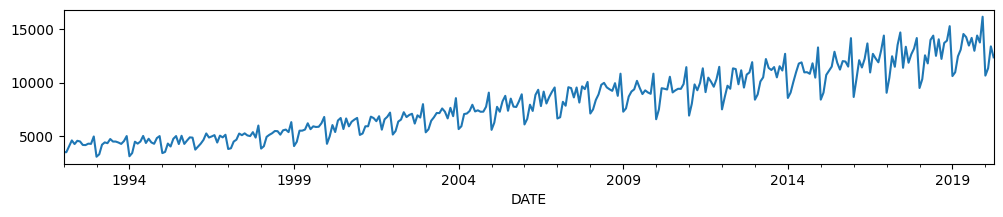

In [6]:
results = seasonal_decompose(df['Sales'])
results.observed.plot(figsize=(12,2))

<Axes: xlabel='DATE'>

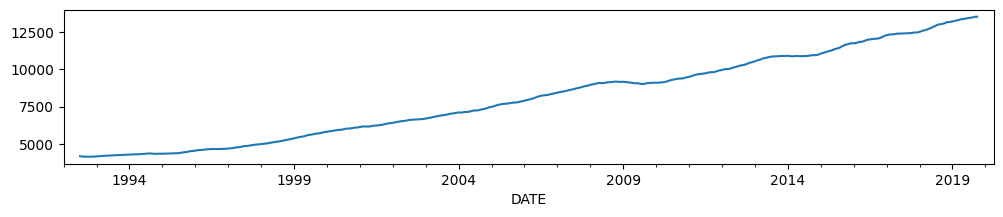

In [7]:
results.trend.plot(figsize=(12,2))

<Axes: xlabel='DATE'>

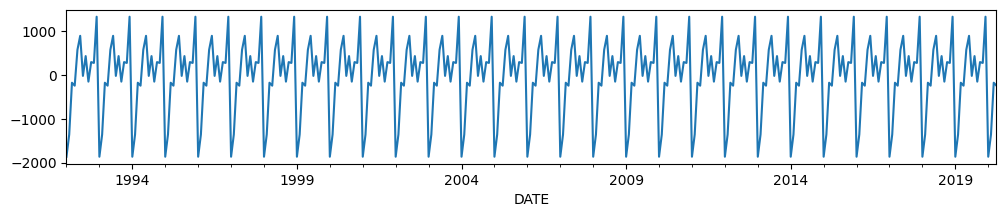

In [8]:
results.seasonal.plot(figsize=(12,2))

<Axes: xlabel='DATE'>

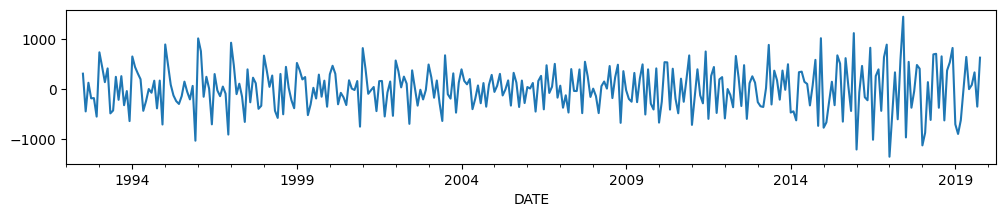

In [9]:
results.resid.plot(figsize=(12,2))

## Train Test Split

In [10]:
len(df)

340

In [11]:
len(df)-12 

328

In [12]:
train = df.iloc[:len(df)-12]
test = df.iloc[len(df)-12:]

In [13]:
len(test)

12

## Escalando los datos

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [15]:
scaler = MinMaxScaler()

In [16]:
scaler.fit(train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [17]:
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

# Time Series Generator

Este generador toma una secuencia de puntos de datos (como una sereie temporal) espaciados en intervalos iguales, teniendo en cuenta otros parámetros de series temporales, para producir batches para el entrenamiento / validación.

#### Argumentos
    data: Indexable generator (such as list or Numpy array)
        containing consecutive data points (timesteps).
        The data should be at 2D, and axis 0 is expected
        to be the time dimension.
    targets: Targets corresponding to timesteps in `data`.
        It should have same length as `data`.
    length: Length of the output sequences (in number of timesteps).
    sampling_rate: Period between successive individual timesteps
        within sequences. For rate `r`, timesteps
        `data[i]`, `data[i-r]`, ... `data[i - length]`
        are used for create a sample sequence.
    stride: Period between successive output sequences.
        For stride `s`, consecutive output samples would
        be centered around `data[i]`, `data[i+s]`, `data[i+2*s]`, etc.
    start_index: Data points earlier than `start_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    end_index: Data points later than `end_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    shuffle: Whether to shuffle output samples,
        or instead draw them in chronological order.
    reverse: Boolean: if `true`, timesteps in each output sample will be
        in reverse chronological order.
    batch_size: Number of timeseries samples in each batch
        (except maybe the last one).

# 🧠 `TimeseriesGenerator` en Keras — Explicación Teórica

## 📌 ¿Qué es `TimeseriesGenerator`?

`TimeseriesGenerator` es una clase de `tensorflow.keras.preprocessing.sequence` utilizada para convertir una serie temporal en pares de entrada/salida que pueden ser usados para entrenar modelos de redes neuronales recurrentes (RNN), como LSTM o GRU.

---

## 🎯 ¿Para qué se usa?

- Preparar automáticamente datos secuenciales.
- Facilitar el entrenamiento de modelos con secuencias como entradas.
- Crear ventanas deslizantes (`sliding windows`) sin tener que escribir lógica manual.

---

## 🧠 ¿Cómo funciona?

Dado un array:


Y un `length = 3`, se generan los siguientes pares entrada/salida:

| Entrada (`X`)      | Salida (`y`) |
|--------------------|--------------|
| [x1, x2, x3]        | x4           |
| [x2, x3, x4]        | x5           |
| [x3, x4, x5]        | x6           |
| ...                | ...          |

---

## ⚙️ Sintaxis

```python
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

generator = TimeseriesGenerator(
    data,         # Serie completa (X + y)
    targets,      # Etiquetas (y)
    length=lookback,   # Longitud de las secuencias de entrada
    batch_size=batch_size
)


In [19]:
#from keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [20]:
scaled_train

array([[0.03486194],
       [0.03478048],
       [0.07909098],
       [0.12486764],
       [0.09692922],
       [0.12201678],
       [0.11688523],
       [0.09008715],
       [0.08919117],
       [0.10002444],
       [0.09847683],
       [0.1551682 ],
       [0.        ],
       [0.01873422],
       [0.09196058],
       [0.1096359 ],
       [0.10393419],
       [0.13561945],
       [0.11623361],
       [0.11615215],
       [0.10857701],
       [0.09815101],
       [0.11965464],
       [0.15826342],
       [0.00358394],
       [0.02818278],
       [0.11501181],
       [0.10018734],
       [0.11639651],
       [0.1591594 ],
       [0.10531889],
       [0.13749287],
       [0.10939155],
       [0.09912845],
       [0.14278733],
       [0.15801906],
       [0.02761261],
       [0.03689827],
       [0.10083897],
       [0.07843936],
       [0.13716706],
       [0.15826342],
       [0.09709212],
       [0.1603812 ],
       [0.09806956],
       [0.12405311],
       [0.14824469],
       [0.146

In [29]:
# Definimos el generator
n_input = 12
n_features = 1
generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)

In [30]:
len(scaled_train)

328

In [31]:
len(generator) # n_input = 2

316

In [32]:
scaled_train[:5]

array([[0.03486194],
       [0.03478048],
       [0.07909098],
       [0.12486764],
       [0.09692922]])

In [33]:
# ¿Cómo luce el primer batch?
generator[0]

(array([[[0.03486194],
         [0.03478048],
         [0.07909098],
         [0.12486764],
         [0.09692922],
         [0.12201678],
         [0.11688523],
         [0.09008715],
         [0.08919117],
         [0.10002444],
         [0.09847683],
         [0.1551682 ]]]),
 array([[0.]]))

In [35]:
X,y = generator[0]

In [36]:
print(f'Datos: \n{X.flatten()}')
print(f'Predicción: \n {y}')

Datos: 
[0.03486194 0.03478048 0.07909098 0.12486764 0.09692922 0.12201678
 0.11688523 0.09008715 0.08919117 0.10002444 0.09847683 0.1551682 ]
Predicción: 
 [[0.]]


In [37]:
# Vamos a redefinir para que utilice 12 meses y luego prediga el próximo mes
n_input = 12
generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)

In [38]:
# ¿Cómo luce el primer batch?
X,y = generator[0]

In [39]:
print(f'Given the Array: \n{X.flatten()}')
print(f'Predict this y: \n {y}')

Given the Array: 
[0.03486194 0.03478048 0.07909098 0.12486764 0.09692922 0.12201678
 0.11688523 0.09008715 0.08919117 0.10002444 0.09847683 0.1551682 ]
Predict this y: 
 [[0.]]


### Creando el Modelo

In [40]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM

In [ ]:
# define model
model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(n_input, n_features)))
#100 neuronas
#relu es la funcion de activacion
#input_shape dimension de entrada, n_input es la longitud de la secuencia, n_features es el número de características (dimension del genereitor)
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

c:\Users\grego\OneDrive\Documentos\cursos\curso-series-temporales\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
# fit model
#model.fit_generator(generator,epochs=50)
model.fit(generator,epochs=100)

Epoch 1/100


316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0012
Epoch 2/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0012
Epoch 3/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0011
Epoch 4/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0012
Epoch 5/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0011
Epoch 6/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0010
Epoch 7/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0012
Epoch 8/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0010  
Epoch 9/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.6351e-04
Epoch 10/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0012
Epoch 11/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0012
Epoch 12/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.8779e-04
Epoch 13/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.8692e-04
Epoch 14/100
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.0650e-04
Epoch 15/100
316/316 ━━━━━━━━━━━━━━━━

In [68]:
model.history.history.keys()

dict_keys(['loss'])

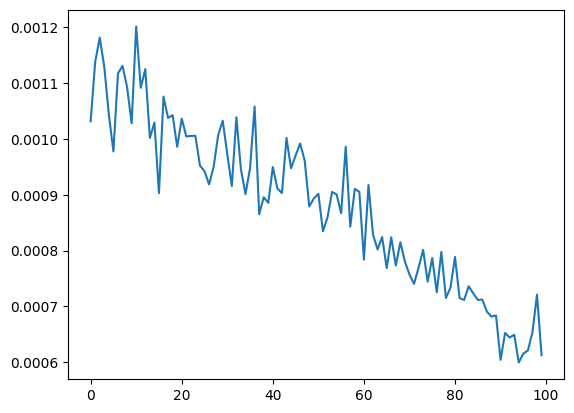

In [69]:
loss_per_epoch = model.history.history['loss']
plt.plot(range(len(loss_per_epoch)),loss_per_epoch)

## Evaluando en los Datos de Prueba (Test)

In [70]:
# 12 meses de historia ---> predecir el 13
# Necesitaremos los últimos 12 meses del conjunto de entrenamiento para predecir el 1er mes en el conjunto de prueba
first_eval_batch = scaled_train[-12:]

In [71]:
first_eval_batch

array([[0.89443675],
       [0.92766963],
       [0.77274578],
       [0.89940539],
       [0.74936874],
       [0.87122261],
       [0.8893052 ],
       [1.        ],
       [0.61782194],
       [0.64714507],
       [0.76899894],
       [0.8199886 ]])

In [72]:
X.shape

(1, 12, 1)

In [73]:
first_eval_batch = first_eval_batch.reshape((1, n_input, n_features))

In [74]:
first_eval_batch.shape

(1, 12, 1)

In [75]:
model.predict(first_eval_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[0.9050763]], dtype=float32)

In [77]:
scaled_test

array([[0.94013195],
       [0.91602183],
       [0.8514295 ],
       [0.9101572 ],
       [0.81135457],
       [0.9282398 ],
       [0.87496946],
       [1.07241183],
       [0.62132443],
       [0.67760854],
       [0.84540197],
       [0.76134235]])

Ahora pongamos esta lógica en un bucle for para predecir el futuro para todo el rango de prueba.
----

In [78]:
test_predictions = []

first_eval_batch = scaled_train[-n_input:]
current_batch = first_eval_batch.reshape((1, n_input, n_features))

for i in range(len(test)):
    
    # obtener la predicción ([0] es para obtener solo el número en lugar de [matriz])
    current_pred = model.predict(current_batch)[0]
    
    # guardar la predicción
    test_predictions.append(current_pred) 
    
    # actualizar el lote para incluir ahora la predicción y soltar primer valor
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [79]:
test_predictions

[array([0.9050763], dtype=float32),
 array([0.99386996], dtype=float32),
 array([0.8530762], dtype=float32),
 array([0.9547304], dtype=float32),
 array([0.7880884], dtype=float32),
 array([0.93130934], dtype=float32),
 array([0.92299473], dtype=float32),
 array([1.0343484], dtype=float32),
 array([0.69193316], dtype=float32),
 array([0.664762], dtype=float32),
 array([0.8108584], dtype=float32),
 array([0.8342103], dtype=float32)]

In [80]:
scaled_test

array([[0.94013195],
       [0.91602183],
       [0.8514295 ],
       [0.9101572 ],
       [0.81135457],
       [0.9282398 ],
       [0.87496946],
       [1.07241183],
       [0.62132443],
       [0.67760854],
       [0.84540197],
       [0.76134235]])

## Transformación inversa y Comparación

In [81]:
true_predictions = scaler.inverse_transform(test_predictions)

In [82]:
true_predictions

array([[14142.62204129],
       [15232.7415027 ],
       [13504.21674752],
       [14752.22501647],
       [12706.3610571 ],
       [14464.68479645],
       [14362.60633528],
       [15729.69492185],
       [11525.86334467],
       [11192.2833209 ],
       [12985.90892643],
       [13272.59956586]])

In [83]:
test

,Sales,Predictions
DATE,,
2019-05-01,14573,14633.030543
2019-06-01,14277,14941.429028
2019-07-01,13484,13429.518051
2019-08-01,14205,14725.020144
2019-09-01,12992,13103.632549
2019-10-01,14427,14525.220889
2019-11-01,13773,14690.967402
2019-12-01,16197,16005.326378
2020-01-01,10659,11082.984522


In [84]:
test['Predictions'] = true_predictions

C:\Users\grego\AppData\Local\Temp\ipykernel_21380\4269337381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


In [85]:
test

,Sales,Predictions
DATE,,
2019-05-01,14573,14142.622041
2019-06-01,14277,15232.741503
2019-07-01,13484,13504.216748
2019-08-01,14205,14752.225016
2019-09-01,12992,12706.361057
2019-10-01,14427,14464.684796
2019-11-01,13773,14362.606335
2019-12-01,16197,15729.694922
2020-01-01,10659,11525.863345


<Axes: xlabel='DATE'>

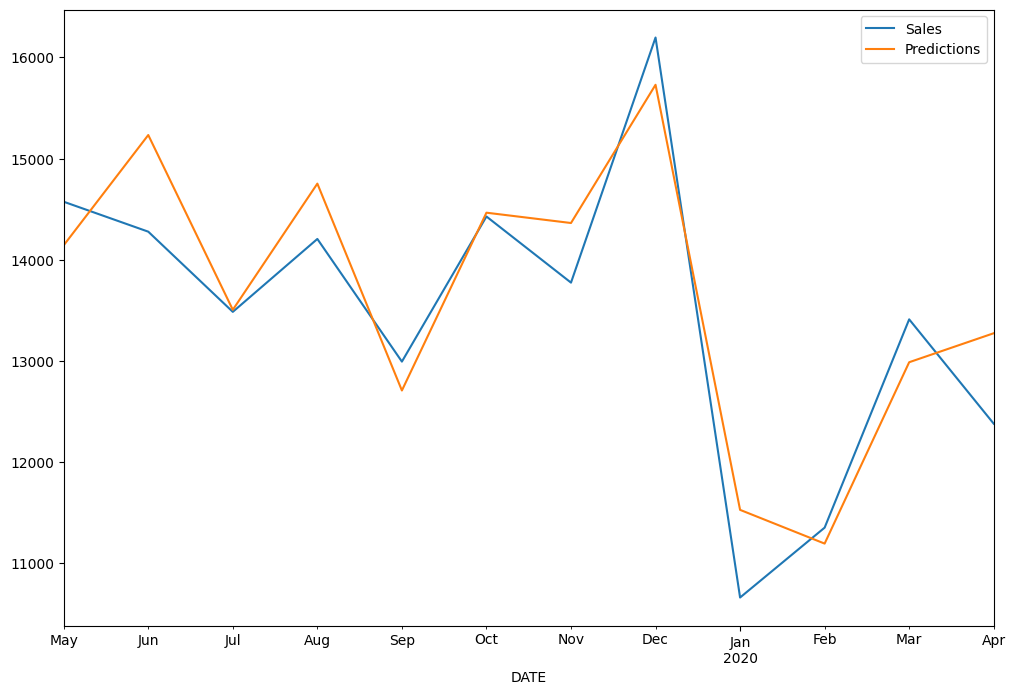

In [86]:
test.plot(figsize=(12,8))

# Guardar un Modelo

In [89]:
#model.save('my_rnn_model.h5')
model.save('my_rnn_model.keras')

# Cargar un Modelo

In [90]:
from keras.models import load_model
new_model = load_model('my_rnn_model.keras')

c:\Users\grego\OneDrive\Documentos\cursos\curso-series-temporales\venv\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 7 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [91]:
new_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,804 (319.55 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 40,903 (159.78 KB)